In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

seed = 42

np.random.seed(seed)
random.seed(seed)

print("Random Seed:", seed)

Random Seed: 42


In [4]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)
    print(files[:5])

/kaggle/input
[]
/kaggle/input/datasets
[]
/kaggle/input/datasets/zalando-research
[]
/kaggle/input/datasets/zalando-research/fashionmnist
['t10k-labels-idx1-ubyte', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 'fashion-mnist_train.csv', 'train-labels-idx1-ubyte']


In [5]:
path = "/kaggle/input/datasets/zalando-research/fashionmnist"

train_df = pd.read_csv(path + "/fashion-mnist_train.csv")
test_df = pd.read_csv(path + "/fashion-mnist_test.csv")

print("Training data:", train_df.shape)
print("Test data:", test_df.shape)

Training data: (60000, 785)
Test data: (10000, 785)


In [6]:
y_train_full = train_df["label"].values
X_train_full = train_df.drop("label", axis=1).values

y_test = test_df["label"].values
X_test = test_df.drop("label", axis=1).values

print("X_train:", X_train_full.shape)
print("y_train:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (60000, 784)
y_train: (60000,)
X_test: (10000, 784)
y_test: (10000,)


In [7]:
print("Minimum pixel value:", X_train_full.min())
print("Maximum pixel value:", X_train_full.max())

Minimum pixel value: 0
Maximum pixel value: 255


## Normalize Training Data

In [8]:
X_train_full = X_train_full.astype("float32") / 255.0
print("After normalization:")
print("Minimum:", X_train_full.min())
print("Maximum:", X_train_full.max())

After normalization:
Minimum: 0.0
Maximum: 1.0


### Train-Validation Split

In [9]:
indices = np.random.permutation(len(X_train_full))

split_index = int(0.8 * len(X_train_full))

train_indices = indices[:split_index]
val_indices = indices[split_index:]

X_train = X_train_full[train_indices]
y_train = y_train_full[train_indices]

X_val = X_train_full[val_indices]
y_val = y_train_full[val_indices]

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 48000
Validation samples: 12000


In [10]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Training Class Distribution:")
for i, name in enumerate(class_names):
    print(i, "-", name, ":", np.sum(y_train == i))

print("\nValidation Class Distribution:")
for i, name in enumerate(class_names):
    print(i, "-", name, ":", np.sum(y_val == i))

Training Class Distribution:
0 - T-shirt/top : 4772
1 - Trouser : 4818
2 - Pullover : 4844
3 - Dress : 4806
4 - Coat : 4782
5 - Sandal : 4786
6 - Shirt : 4818
7 - Sneaker : 4777
8 - Bag : 4818
9 - Ankle boot : 4779

Validation Class Distribution:
0 - T-shirt/top : 1228
1 - Trouser : 1182
2 - Pullover : 1156
3 - Dress : 1194
4 - Coat : 1218
5 - Sandal : 1214
6 - Shirt : 1182
7 - Sneaker : 1223
8 - Bag : 1182
9 - Ankle boot : 1221


In [11]:
X_part1 = X_train[:5000]
y_part1 = y_train[:5000]

print("Part 1 Training Samples:", X_part1.shape)
print("Part 1 Labels:", y_part1.shape)

Part 1 Training Samples: (5000, 784)
Part 1 Labels: (5000,)


## Network Architecture

In [12]:
rng = np.random.default_rng(seed)

W1 = (
    rng.standard_normal((784, 64)).astype(np.float32)
    * np.sqrt(2 / 784)
)

b1 = np.zeros(64, dtype=np.float32)

W2 = (
    rng.standard_normal((64, 10)).astype(np.float32)
    * np.sqrt(2 / 64)
)

b2 = np.zeros(10, dtype=np.float32)

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (784, 64)
b1: (64,)
W2: (64, 10)
b2: (10,)


In [13]:
def relu(x):
    return np.maximum(0, x)

In [14]:
def softmax(x):
    x = x - np.max(x, axis=1, keepdims=True)

    exp_x = np.exp(x)

    return exp_x / np.sum(
        exp_x,
        axis=1,
        keepdims=True
    )

## Forward Propagation

In [15]:
def forward(X, W1, b1, W2, b2):

    Z1 = X @ W1 + b1

    A1 = relu(Z1)

    Z2 = A1 @ W2 + b2

    Y_hat = softmax(Z2)

    cache = (X, Z1, A1, Z2, Y_hat)

    return Y_hat, cache

In [16]:
def cross_entropy(y_true, y_pred):

    n = y_true.shape[0]

    correct_class_probs = y_pred[
        np.arange(n),
        y_true
    ]

    loss = -np.log(
        correct_class_probs + 1e-12
    )

    return np.mean(loss)

In [17]:
def backward(y_true, cache, W2):

    X, Z1, A1, Z2, Y_hat = cache

    n = X.shape[0]

    # Output layer ka gradient
    dZ2 = Y_hat.copy()

    dZ2[
        np.arange(n),
        y_true
    ] -= 1

    dZ2 /= n

    # second layer k gradients
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0)

    # hidden layer tk k gradient
    dA1 = dZ2 @ W2.T

    # ReLU ki derivative
    dZ1 = dA1 * (Z1 > 0)

    # first layer k gradient
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0)

    return {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2
    }

In [18]:
learning_rate = 0.01
epochs = 20

loss_history = []

for epoch in range(epochs):

    # Forward propagation
    y_pred, cache = forward(
        X_part1,
        W1,
        b1,
        W2,
        b2
    )

    # Calculate loss
    loss = cross_entropy(
        y_part1,
        y_pred
    )

    # Backpropagation
    gradients = backward(
        y_part1,
        cache,
        W2
    )

    # Gradient descent update
    W1 -= learning_rate * gradients["dW1"]
    b1 -= learning_rate * gradients["db1"]

    W2 -= learning_rate * gradients["dW2"]
    b2 -= learning_rate * gradients["db2"]

    loss_history.append(loss)

    print(
        f"Epoch {epoch + 1:02d}/{epochs} "
        f"- Loss: {loss:.4f}"
    )

Epoch 01/20 - Loss: 2.3890
Epoch 02/20 - Loss: 2.3372
Epoch 03/20 - Loss: 2.2944
Epoch 04/20 - Loss: 2.2578
Epoch 05/20 - Loss: 2.2254
Epoch 06/20 - Loss: 2.1962
Epoch 07/20 - Loss: 2.1696
Epoch 08/20 - Loss: 2.1452
Epoch 09/20 - Loss: 2.1226
Epoch 10/20 - Loss: 2.1015
Epoch 11/20 - Loss: 2.0818
Epoch 12/20 - Loss: 2.0632
Epoch 13/20 - Loss: 2.0456
Epoch 14/20 - Loss: 2.0288
Epoch 15/20 - Loss: 2.0126
Epoch 16/20 - Loss: 1.9970
Epoch 17/20 - Loss: 1.9820
Epoch 18/20 - Loss: 1.9673
Epoch 19/20 - Loss: 1.9531
Epoch 20/20 - Loss: 1.9392


## lose curve

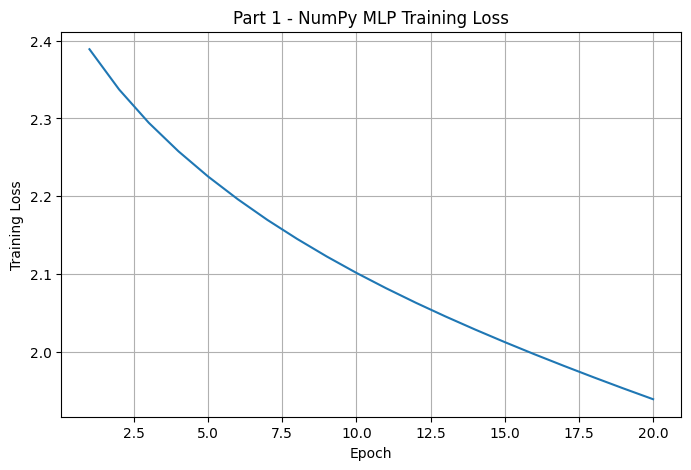

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part 1 - NumPy MLP Training Loss")
plt.grid()

plt.show()

In [20]:
import torch
import torch.nn as nn

In [21]:
class MLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):

        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)

        return x

In [22]:
model = MLP()

with torch.no_grad():

    model.fc1.weight.copy_(
        torch.tensor(W1.T)
    )

    model.fc1.bias.copy_(
        torch.tensor(b1)
    )

    model.fc2.weight.copy_(
        torch.tensor(W2.T)
    )

    model.fc2.bias.copy_(
        torch.tensor(b2)
    )

### Data prepare

In [23]:
X_tensor = torch.tensor(X_part1, dtype=torch.float32)
y_tensor = torch.tensor(y_part1, dtype=torch.long)

criterion = nn.CrossEntropyLoss()

## forwrd with torch

In [24]:
model.zero_grad()

logits = model(X_tensor)

loss_torch = criterion(logits, y_tensor)

print("PyTorch Loss:", loss_torch.item())

PyTorch Loss: 1.9257160425186157


## backwrd with torch

In [25]:
loss_torch.backward()

In [26]:
rng_check = np.random.default_rng(seed)

W1_check = (
    rng_check.standard_normal((784, 64)).astype(np.float32)
    * np.sqrt(2 / 784)
)

b1_check = np.zeros(64, dtype=np.float32)

W2_check = (
    rng_check.standard_normal((64, 10)).astype(np.float32)
    * np.sqrt(2 / 64)
)

b2_check = np.zeros(10, dtype=np.float32)

In [27]:
y_pred_check, cache_check = forward(
    X_part1,
    W1_check,
    b1_check,
    W2_check,
    b2_check
)

loss_check = cross_entropy(
    y_part1,
    y_pred_check
)

grads_check = backward(
    y_part1,
    cache_check,
    W2_check
)

print("NumPy Loss:", loss_check)

NumPy Loss: 2.388968655888244


In [28]:
model_check = MLP()

with torch.no_grad():

    model_check.fc1.weight.copy_(
        torch.tensor(W1_check.T)
    )

    model_check.fc1.bias.copy_(
        torch.tensor(b1_check)
    )

    model_check.fc2.weight.copy_(
        torch.tensor(W2_check.T)
    )

    model_check.fc2.bias.copy_(
        torch.tensor(b2_check)
    )

In [29]:
model_check.zero_grad()

logits = model_check(X_tensor)

loss_torch_check = criterion(
    logits,
    y_tensor
)

loss_torch_check.backward()

print("PyTorch Loss:", loss_torch_check.item())

PyTorch Loss: 2.3889682292938232


In [30]:
pt_dW1 = model_check.fc1.weight.grad.detach().numpy().T
pt_db1 = model_check.fc1.bias.grad.detach().numpy()

pt_dW2 = model_check.fc2.weight.grad.detach().numpy().T
pt_db2 = model_check.fc2.bias.grad.detach().numpy()

print("PyTorch gradients extracted.")

PyTorch gradients extracted.


In [31]:
diff_W1 = np.max(np.abs(grads_check["dW1"] - pt_dW1))
diff_b1 = np.max(np.abs(grads_check["db1"] - pt_db1))
diff_W2 = np.max(np.abs(grads_check["dW2"] - pt_dW2))
diff_b2 = np.max(np.abs(grads_check["db2"] - pt_db2))

max_difference = max(diff_W1, diff_b1, diff_W2, diff_b2)

print("Maximum Absolute Difference:", max_difference)

Maximum Absolute Difference: 1.8545230337507768e-08


## Part-II

In [32]:
from torch.utils.data import TensorDataset, DataLoader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### Training aur Validation Data ko PyTorch Tensor mein convert karo

In [33]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

print("Training:", X_train_tensor.shape)
print("Validation:", X_val_tensor.shape)

Training: torch.Size([48000, 784])
Validation: torch.Size([12000, 784])


In [34]:
batch_size = 64

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Batch Size:", batch_size)

Batch Size: 64


## Model Architecture

In [35]:
class ActivationMLP(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.hidden1 = nn.Linear(784, 128)
        self.hidden2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 10)

        self.activation = activation

    def forward(self, x):
        x = self.hidden1(x)
        x = self.activation(x)

        x = self.hidden2(x)
        x = self.activation(x)

        x = self.output(x)

        return x

## starting weights of all layer or neural network

In [36]:
torch.manual_seed(42)

base_model = ActivationMLP(nn.ReLU())

initial_weights = {
    name: param.detach().clone()
    for name, param in base_model.state_dict().items()
}

print("Same initial weights prepared.")

Same initial weights prepared.


### training setting

In [37]:
learning_rate = 0.01
epochs = 20

criterion = nn.CrossEntropyLoss()

print("Learning Rate:", learning_rate)
print("Epochs:", epochs)
print("Batch Size:", batch_size)
print("Optimizer: SGD")

Learning Rate: 0.01
Epochs: 20
Batch Size: 64
Optimizer: SGD


In [38]:
def train_model(activation, activation_name):
    
    model = ActivationMLP(activation).to(device)

    # Same initial weights
    model.load_state_dict(initial_weights)

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=learning_rate
    )

    validation_losses = []

    epoch1_gradient = None
    final_gradient = None

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()

            # Record first hidden layer gradient
            if epoch == 0:
                epoch1_gradient = (
                    torch.abs(model.hidden1.weight.grad)
                    .mean()
                    .item()
                )

            if epoch == epochs - 1:
                final_gradient = (
                    torch.abs(model.hidden1.weight.grad)
                    .mean()
                    .item()
                )

            optimizer.step()

        # Validation
        model.eval()

        total_val_loss = 0
        total_samples = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                val_loss = criterion(outputs, y_batch)

                total_val_loss += val_loss.item() * X_batch.size(0)
                total_samples += X_batch.size(0)

        average_val_loss = total_val_loss / total_samples

        validation_losses.append(average_val_loss)

        print(
            f"{activation_name} - "
            f"Epoch {epoch + 1:02d}/{epochs} - "
            f"Validation Loss: {average_val_loss:.4f}"
        )

    return model, validation_losses, epoch1_gradient, final_gradient

In [39]:
sigmoid_model, sigmoid_losses, sigmoid_grad_epoch1, sigmoid_grad_final = train_model(
    nn.Sigmoid(),
    "Sigmoid"
)

Sigmoid - Epoch 01/20 - Validation Loss: 2.2939
Sigmoid - Epoch 02/20 - Validation Loss: 2.2772
Sigmoid - Epoch 03/20 - Validation Loss: 2.2382
Sigmoid - Epoch 04/20 - Validation Loss: 2.1231
Sigmoid - Epoch 05/20 - Validation Loss: 1.8589
Sigmoid - Epoch 06/20 - Validation Loss: 1.6343
Sigmoid - Epoch 07/20 - Validation Loss: 1.4679
Sigmoid - Epoch 08/20 - Validation Loss: 1.3386
Sigmoid - Epoch 09/20 - Validation Loss: 1.2444
Sigmoid - Epoch 10/20 - Validation Loss: 1.1714
Sigmoid - Epoch 11/20 - Validation Loss: 1.1138
Sigmoid - Epoch 12/20 - Validation Loss: 1.0662
Sigmoid - Epoch 13/20 - Validation Loss: 1.0248
Sigmoid - Epoch 14/20 - Validation Loss: 0.9880
Sigmoid - Epoch 15/20 - Validation Loss: 0.9546
Sigmoid - Epoch 16/20 - Validation Loss: 0.9240
Sigmoid - Epoch 17/20 - Validation Loss: 0.8956
Sigmoid - Epoch 18/20 - Validation Loss: 0.8693
Sigmoid - Epoch 19/20 - Validation Loss: 0.8451
Sigmoid - Epoch 20/20 - Validation Loss: 0.8218


In [40]:
tanh_model, tanh_losses, tanh_grad_epoch1, tanh_grad_final = train_model(
    nn.Tanh(),
    "Tanh"
)

Tanh - Epoch 01/20 - Validation Loss: 0.9199
Tanh - Epoch 02/20 - Validation Loss: 0.6976
Tanh - Epoch 03/20 - Validation Loss: 0.6033
Tanh - Epoch 04/20 - Validation Loss: 0.5478
Tanh - Epoch 05/20 - Validation Loss: 0.5150
Tanh - Epoch 06/20 - Validation Loss: 0.4906
Tanh - Epoch 07/20 - Validation Loss: 0.4745
Tanh - Epoch 08/20 - Validation Loss: 0.4601
Tanh - Epoch 09/20 - Validation Loss: 0.4496
Tanh - Epoch 10/20 - Validation Loss: 0.4420
Tanh - Epoch 11/20 - Validation Loss: 0.4370
Tanh - Epoch 12/20 - Validation Loss: 0.4301
Tanh - Epoch 13/20 - Validation Loss: 0.4184
Tanh - Epoch 14/20 - Validation Loss: 0.4133
Tanh - Epoch 15/20 - Validation Loss: 0.4098
Tanh - Epoch 16/20 - Validation Loss: 0.4053
Tanh - Epoch 17/20 - Validation Loss: 0.3988
Tanh - Epoch 18/20 - Validation Loss: 0.3958
Tanh - Epoch 19/20 - Validation Loss: 0.3928
Tanh - Epoch 20/20 - Validation Loss: 0.3888


In [41]:
relu_model, relu_losses, relu_grad_epoch1, relu_grad_final = train_model(
    nn.ReLU(),
    "ReLU"
)

ReLU - Epoch 01/20 - Validation Loss: 0.9215
ReLU - Epoch 02/20 - Validation Loss: 0.7067
ReLU - Epoch 03/20 - Validation Loss: 0.6050
ReLU - Epoch 04/20 - Validation Loss: 0.5497
ReLU - Epoch 05/20 - Validation Loss: 0.5774
ReLU - Epoch 06/20 - Validation Loss: 0.4991
ReLU - Epoch 07/20 - Validation Loss: 0.4795
ReLU - Epoch 08/20 - Validation Loss: 0.4718
ReLU - Epoch 09/20 - Validation Loss: 0.4575
ReLU - Epoch 10/20 - Validation Loss: 0.4556
ReLU - Epoch 11/20 - Validation Loss: 0.4431
ReLU - Epoch 12/20 - Validation Loss: 0.4344
ReLU - Epoch 13/20 - Validation Loss: 0.4256
ReLU - Epoch 14/20 - Validation Loss: 0.4271
ReLU - Epoch 15/20 - Validation Loss: 0.4172
ReLU - Epoch 16/20 - Validation Loss: 0.4215
ReLU - Epoch 17/20 - Validation Loss: 0.4174
ReLU - Epoch 18/20 - Validation Loss: 0.4043
ReLU - Epoch 19/20 - Validation Loss: 0.4036
ReLU - Epoch 20/20 - Validation Loss: 0.3988


In [42]:
leaky_relu_model, leaky_relu_losses, leaky_relu_grad_epoch1, leaky_relu_grad_final = train_model(
    nn.LeakyReLU(),
    "LeakyReLU"
)

LeakyReLU - Epoch 01/20 - Validation Loss: 0.9334
LeakyReLU - Epoch 02/20 - Validation Loss: 0.7005
LeakyReLU - Epoch 03/20 - Validation Loss: 0.6205
LeakyReLU - Epoch 04/20 - Validation Loss: 0.5563
LeakyReLU - Epoch 05/20 - Validation Loss: 0.5190
LeakyReLU - Epoch 06/20 - Validation Loss: 0.5198
LeakyReLU - Epoch 07/20 - Validation Loss: 0.4954
LeakyReLU - Epoch 08/20 - Validation Loss: 0.4712
LeakyReLU - Epoch 09/20 - Validation Loss: 0.4688
LeakyReLU - Epoch 10/20 - Validation Loss: 0.4507
LeakyReLU - Epoch 11/20 - Validation Loss: 0.4509
LeakyReLU - Epoch 12/20 - Validation Loss: 0.4421
LeakyReLU - Epoch 13/20 - Validation Loss: 0.4291
LeakyReLU - Epoch 14/20 - Validation Loss: 0.4345
LeakyReLU - Epoch 15/20 - Validation Loss: 0.4213
LeakyReLU - Epoch 16/20 - Validation Loss: 0.4225
LeakyReLU - Epoch 17/20 - Validation Loss: 0.4194
LeakyReLU - Epoch 18/20 - Validation Loss: 0.4088
LeakyReLU - Epoch 19/20 - Validation Loss: 0.4031
LeakyReLU - Epoch 20/20 - Validation Loss: 0.4098


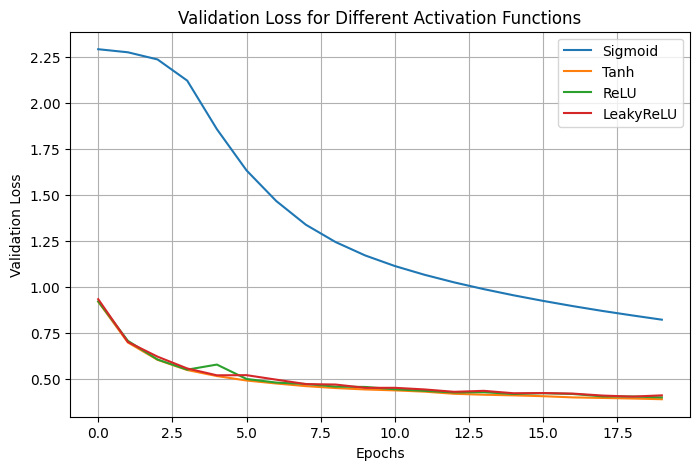

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(sigmoid_losses, label="Sigmoid")
plt.plot(tanh_losses, label="Tanh")
plt.plot(relu_losses, label="ReLU")
plt.plot(leaky_relu_losses, label="LeakyReLU")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss for Different Activation Functions")
plt.legend()
plt.grid()

plt.show()

In [44]:
print("First Hidden Layer Mean Absolute Gradient")
print("\n       *****************************\n")
print("Sigmoid:")
print("Epoch 1   :", sigmoid_grad_epoch1)
print("Final Epoch:", sigmoid_grad_final)
print("\n       *****************************\n")
print("ReLU:")
print("Epoch 1   :", relu_grad_epoch1)
print("Final Epoch:", relu_grad_final)

First Hidden Layer Mean Absolute Gradient

       *****************************

Sigmoid:
Epoch 1   : 0.00010475100862095132
Final Epoch: 0.0003204593376722187

       *****************************

ReLU:
Epoch 1   : 0.0009001987637020648
Final Epoch: 0.0023401209618896246


## Dead ReLU Percentage

In [45]:
relu_model.eval()
# First validation batch
X_val_batch, y_val_batch = next(iter(val_loader))
X_val_batch = X_val_batch.to(device)
with torch.no_grad():

    # First hidden layer
    hidden1_output = relu_model.hidden1(X_val_batch)
    # ReLU activation
    hidden1_output = relu_model.activation(hidden1_output)

# Check karna k kon sa neuron all sample k liya zero ha
dead_units = torch.all(hidden1_output == 0, dim=0)
number_of_dead_units = dead_units.sum().item()
total_units = hidden1_output.shape[1]
dead_percentage = (number_of_dead_units / total_units) * 100

print("Total Hidden Units:", total_units)
print("Dead ReLU Units:", number_of_dead_units)
print("Dead ReLU Percentage:", dead_percentage, "%")

Total Hidden Units: 128
Dead ReLU Units: 4
Dead ReLU Percentage: 3.125 %


# Explanation:

## Vanishing Gradients: 
                    Numbers ke basis par Sigmoid ka mean absolute gradient 0.00010475 se 0.00032046 hua, yani is experiment mein gradient decrease nahi hua. Therefore, these results do not show a clear vanishing-gradient trend in the Sigmoid model from Epoch 1 to the final epoch.

## Dead ReLU: 
            ReLU model mein 128 hidden units mein se 4 units completely inactive thay, resulting in a dead-unit percentage of 3.125%. Ye dead units learning mein contribute nahi karte, jis ki wajah se model ki learning capacity thori kam ho jati hai.

# Part-III

In [46]:
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 48000
Validation samples: 12000


In [47]:
torch.manual_seed(42)

# Same architecture + same initial weights
ce_model = ActivationMLP(nn.ReLU())
mse_model = ActivationMLP(nn.ReLU())

ce_model.load_state_dict(initial_weights)
mse_model.load_state_dict(initial_weights)

print("Both models have same architecture and initial weights.")

Both models have same architecture and initial weights.


In [48]:
def one_hot_encode(labels, num_classes=10):
    return torch.nn.functional.one_hot(
        labels, num_classes=num_classes
    ).float()

In [49]:
ce_optimizer = torch.optim.SGD(
    ce_model.parameters(),
    lr=learning_rate
)

ce_criterion = nn.CrossEntropyLoss()

ce_train_losses = []

for epoch in range(epochs):

    ce_model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        ce_optimizer.zero_grad()

        outputs = ce_model(X_batch)

        loss = ce_criterion(outputs, y_batch)

        loss.backward()
        ce_optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    ce_train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - CE Loss: {avg_loss:.4f}")

Epoch [1/20] - CE Loss: 1.5554
Epoch [2/20] - CE Loss: 0.7813
Epoch [3/20] - CE Loss: 0.6481
Epoch [4/20] - CE Loss: 0.5762
Epoch [5/20] - CE Loss: 0.5320
Epoch [6/20] - CE Loss: 0.5055
Epoch [7/20] - CE Loss: 0.4875
Epoch [8/20] - CE Loss: 0.4708
Epoch [9/20] - CE Loss: 0.4596
Epoch [10/20] - CE Loss: 0.4482
Epoch [11/20] - CE Loss: 0.4390
Epoch [12/20] - CE Loss: 0.4315
Epoch [13/20] - CE Loss: 0.4238
Epoch [14/20] - CE Loss: 0.4177
Epoch [15/20] - CE Loss: 0.4109
Epoch [16/20] - CE Loss: 0.4056
Epoch [17/20] - CE Loss: 0.3986
Epoch [18/20] - CE Loss: 0.3944
Epoch [19/20] - CE Loss: 0.3898
Epoch [20/20] - CE Loss: 0.3866


In [50]:
mse_optimizer = torch.optim.SGD(
    mse_model.parameters(),
    lr=learning_rate
)

mse_criterion = nn.MSELoss()

mse_train_losses = []

for epoch in range(epochs):

    mse_model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        mse_optimizer.zero_grad()

        outputs = mse_model(X_batch)

        # Convert logits into probabilities
        probabilities = torch.softmax(outputs, dim=1)

        # One-hot targets
        y_one_hot = one_hot_encode(y_batch)

        loss = mse_criterion(probabilities, y_one_hot)

        loss.backward()
        mse_optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    avg_loss = total_loss / len(train_loader.dataset)
    mse_train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{epochs}] - MSE Loss: {avg_loss:.4f}")

Epoch [1/20] - MSE Loss: 0.0900
Epoch [2/20] - MSE Loss: 0.0897
Epoch [3/20] - MSE Loss: 0.0894
Epoch [4/20] - MSE Loss: 0.0891
Epoch [5/20] - MSE Loss: 0.0888
Epoch [6/20] - MSE Loss: 0.0885
Epoch [7/20] - MSE Loss: 0.0881
Epoch [8/20] - MSE Loss: 0.0876
Epoch [9/20] - MSE Loss: 0.0870
Epoch [10/20] - MSE Loss: 0.0862
Epoch [11/20] - MSE Loss: 0.0853
Epoch [12/20] - MSE Loss: 0.0840
Epoch [13/20] - MSE Loss: 0.0824
Epoch [14/20] - MSE Loss: 0.0805
Epoch [15/20] - MSE Loss: 0.0782
Epoch [16/20] - MSE Loss: 0.0759
Epoch [17/20] - MSE Loss: 0.0737
Epoch [18/20] - MSE Loss: 0.0715
Epoch [19/20] - MSE Loss: 0.0693
Epoch [20/20] - MSE Loss: 0.0671


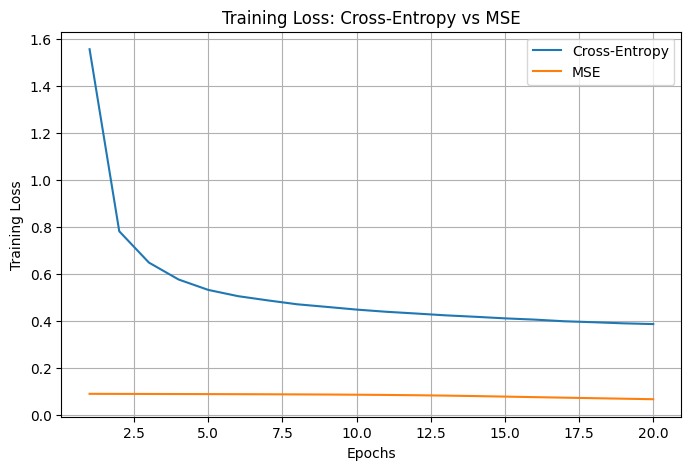

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    ce_train_losses,
    label="Cross-Entropy"
)

plt.plot(
    range(1, epochs + 1),
    mse_train_losses,
    label="MSE"
)

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss: Cross-Entropy vs MSE")
plt.legend()
plt.grid()
plt.show()

# Take small dta for Samll MLP

**Load & Preprocess the Data**

In [3]:
 
import os
import pandas as pd

csv_files = []
for root, _, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))

print("All CSV files found under /kaggle/input:")
for p in csv_files:
    print("  ", p)

# Auto-pick the insurance one
insurance_path = next(
    (p for p in csv_files if "insurance" in p.lower()),
    None
)

if insurance_path is None:
    raise FileNotFoundError(
        "No insurance CSV found. Did you attach the dataset?\n"
        "Right sidebar → Add Input → search 'Medical Insurance Cost Prediction'."
    )

print("\n>>> Using file:", insurance_path)

All CSV files found under /kaggle/input:
   /kaggle/input/datasets/rahulvyasm/medical-insurance-cost-prediction/medical_insurance.csv
   /kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
   /kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv

>>> Using file: /kaggle/input/datasets/rahulvyasm/medical-insurance-cost-prediction/medical_insurance.csv


In [4]:

#  Load data

df = pd.read_csv(insurance_path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())
print("\nData types & nulls:")
print(df.info())

Shape: (2772, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Data types & nulls:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), o

**Preprocess one-hot encode categoricals**

In [5]:
 
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Categorical columns to encode
categorical_cols = ['sex', 'smoker', 'region']

# One-hot encode  
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)
print("Columns after encoding:", df_encoded.columns.tolist())

# Separate features and target
target_col = 'charges'
X = df_encoded.drop(columns=[target_col]).values.astype(np.float32)
y = df_encoded[target_col].values.astype(np.float32)

print("\nX shape:", X.shape)
print("y shape:", y.shape)
print("Target range: $", y.min(), "- $", y.max())

Shape after encoding: (2772, 9)
Columns after encoding: ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

X shape: (2772, 8)
y shape: (2772,)
Target range: $ 1121.8739 - $ 63770.43


**Train/test split + standardization**

In [6]:
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit on train only
X_test  = scaler.transform(X_test)        # apply to test

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (2217, 8) | Test: (555, 8)


**Convert to tensors and DataLoaders**

In [7]:
 
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).view(-1, 1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

Device: cuda
Train batches: 70
Test batches : 9


**Define the regression MLP**

In [8]:
 
class InsuranceMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
input_dim = X_train.shape[1]
model = InsuranceMLP(input_dim).to(device)

print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters()))

InsuranceMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Trainable params: 2689


**Train the model**

In [9]:
 
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

epochs = 100
train_losses = []

torch.manual_seed(42)

for epoch in range(epochs):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)

    avg_loss = running / len(train_ds)
    train_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d}/{epochs} | Train MSE: {avg_loss:,.2f}")

Epoch 020/100 | Train MSE: 53,678,042.98
Epoch 040/100 | Train MSE: 33,653,171.74
Epoch 060/100 | Train MSE: 32,706,693.54
Epoch 080/100 | Train MSE: 31,648,834.47
Epoch 100/100 | Train MSE: 30,436,848.01


**Evaluate on test set (MSE, RMSE, MAE)**

In [10]:
 
model.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        pred = model(xb).cpu().numpy()
        all_preds.append(pred)
        all_targets.append(yb.numpy())

all_preds   = np.concatenate(all_preds).flatten()
all_targets = np.concatenate(all_targets).flatten()

mse  = np.mean((all_preds - all_targets) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(all_preds - all_targets))

print("=" * 50)
print(" Regression MLP — Medical Insurance Test Metrics")
print("=" * 50)
print(f" MSE  : ${mse:,.2f}")
print(f" RMSE : ${rmse:,.2f}")
print(f" MAE  : ${mae:,.2f}")
print("=" * 50)

 Regression MLP — Medical Insurance Test Metrics
 MSE  : $35,064,764.00
 RMSE : $5,921.55
 MAE  : $3,723.27


**Training curve plot**

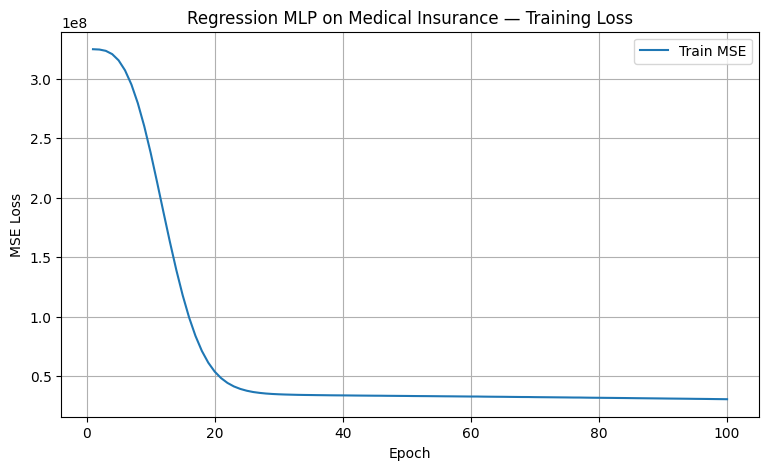

In [11]:
 
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Train MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Regression MLP on Medical Insurance — Training Loss")
plt.legend()
plt.grid()
plt.show()

**Predicted vs actual scatter**

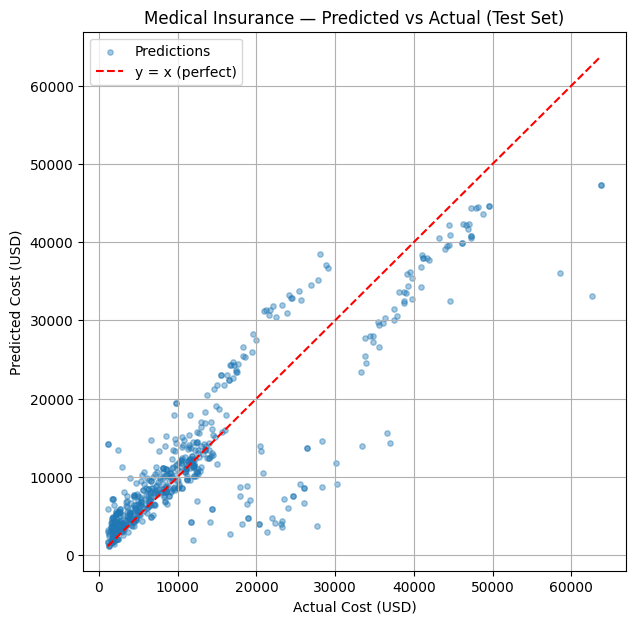

In [12]:
 
plt.figure(figsize=(7, 7))
plt.scatter(all_targets, all_preds, alpha=0.4, s=15, label="Predictions")
lims = [min(all_targets.min(), all_preds.min()),
        max(all_targets.max(), all_preds.max())]
plt.plot(lims, lims, "r--", label="y = x (perfect)")
plt.xlabel("Actual Cost (USD)")
plt.ylabel("Predicted Cost (USD)")
plt.title("Medical Insurance — Predicted vs Actual (Test Set)")
plt.legend()
plt.grid()
plt.show()

**Summary table**

In [13]:
 
import pandas as pd

df_reg = pd.DataFrame([{
    "Dataset": "Medical Insurance (Kaggle)",
    "Samples": len(df),
    "Features": X.shape[1],
    "Model": "MLP 8→64→32→1",
    "Epochs": epochs,
    "MSE": f"${mse:,.2f}",
    "RMSE": f"${rmse:,.2f}",
    "MAE": f"${mae:,.2f}",
}])

print("===== Part 3 — Regression Metrics =====")
print(df_reg.to_string(index=False))

===== Part 3 — Regression Metrics =====
                   Dataset  Samples  Features         Model  Epochs            MSE      RMSE       MAE
Medical Insurance (Kaggle)     2772         8 MLP 8→64→32→1     100 $35,064,764.00 $5,921.55 $3,723.27


Cross-entropy is the natural loss for a softmax output layer. Its gradient with respect to the logits simplifies to softmax(z) − one_hot(y) — a clean residual that is large when the model is confidently wrong and small when it is confidently correct. Every weight update is therefore proportional to the prediction error and well-scaled from the first epoch.

MSE, by contrast, must back-propagate through the softmax. Its gradient with respect to the logits passes through the softmax Jacobian, whose entries are bounded by σ(1 − σ) ≤ 0.25 per class. When the model is confidently wrong — exactly the case that needs a large corrective step — the softmax derivative collapses toward zero, so the gradient reaching the weights is severely suppressed. This is the same vanishing-gradient failure mode seen with sigmoid activations

# Part-IV

In [52]:
torch.manual_seed(42)

base_model = ActivationMLP(nn.ReLU())

initial_weights = {
    name: param.detach().clone()
    for name, param in base_model.state_dict().items()
}

print("Same initial weights are ready.")

Same initial weights are ready.


In [53]:
import time

def train_optimizer(model, optimizer, epochs=20):

    train_losses = []
    val_accuracies = []

    start_time = time.time()

    for epoch in range(epochs):

        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = nn.CrossEntropyLoss()(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

        avg_loss = total_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        # Validation accuracy
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                outputs = model(X_batch)
                predictions = torch.argmax(outputs, dim=1)

                correct += (predictions == y_batch).sum().item()
                total += y_batch.size(0)

        accuracy = (correct / total) * 100
        val_accuracies.append(accuracy)

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {avg_loss:.4f}, "
            f"Val Accuracy = {accuracy:.2f}%"
        )

    elapsed_time = time.time() - start_time

    return train_losses, val_accuracies, elapsed_time

## SGD

In [54]:
sgd_model = ActivationMLP(nn.ReLU())
sgd_model.load_state_dict(initial_weights)

sgd_optimizer = torch.optim.SGD(
    sgd_model.parameters(),
    lr=0.01
)

sgd_loss, sgd_acc, sgd_time = train_optimizer(
    sgd_model,
    sgd_optimizer
)

Epoch 1: Loss = 1.5554, Val Accuracy = 67.14%
Epoch 2: Loss = 0.7817, Val Accuracy = 75.76%
Epoch 3: Loss = 0.6481, Val Accuracy = 79.03%
Epoch 4: Loss = 0.5762, Val Accuracy = 80.77%
Epoch 5: Loss = 0.5335, Val Accuracy = 80.28%
Epoch 6: Loss = 0.5061, Val Accuracy = 82.03%
Epoch 7: Loss = 0.4866, Val Accuracy = 82.33%
Epoch 8: Loss = 0.4711, Val Accuracy = 82.93%
Epoch 9: Loss = 0.4591, Val Accuracy = 83.51%
Epoch 10: Loss = 0.4484, Val Accuracy = 82.69%
Epoch 11: Loss = 0.4395, Val Accuracy = 84.20%
Epoch 12: Loss = 0.4299, Val Accuracy = 84.45%
Epoch 13: Loss = 0.4234, Val Accuracy = 85.45%
Epoch 14: Loss = 0.4168, Val Accuracy = 84.82%
Epoch 15: Loss = 0.4099, Val Accuracy = 85.47%
Epoch 16: Loss = 0.4045, Val Accuracy = 85.62%
Epoch 17: Loss = 0.3999, Val Accuracy = 85.58%
Epoch 18: Loss = 0.3946, Val Accuracy = 86.05%
Epoch 19: Loss = 0.3891, Val Accuracy = 86.13%
Epoch 20: Loss = 0.3853, Val Accuracy = 86.02%


## SGD and Momentum

In [55]:
momentum_model = ActivationMLP(nn.ReLU())
momentum_model.load_state_dict(initial_weights)

momentum_optimizer = torch.optim.SGD(
    momentum_model.parameters(),
    lr=0.01,
    momentum=0.9
)

momentum_loss, momentum_acc, momentum_time = train_optimizer(
    momentum_model,
    momentum_optimizer
)

Epoch 1: Loss = 0.7420, Val Accuracy = 82.32%
Epoch 2: Loss = 0.4603, Val Accuracy = 83.91%
Epoch 3: Loss = 0.4075, Val Accuracy = 84.11%
Epoch 4: Loss = 0.3781, Val Accuracy = 86.11%
Epoch 5: Loss = 0.3566, Val Accuracy = 86.59%
Epoch 6: Loss = 0.3390, Val Accuracy = 87.39%
Epoch 7: Loss = 0.3231, Val Accuracy = 87.98%
Epoch 8: Loss = 0.3111, Val Accuracy = 87.64%
Epoch 9: Loss = 0.2982, Val Accuracy = 88.40%
Epoch 10: Loss = 0.2898, Val Accuracy = 88.47%
Epoch 11: Loss = 0.2792, Val Accuracy = 87.91%
Epoch 12: Loss = 0.2752, Val Accuracy = 88.56%
Epoch 13: Loss = 0.2682, Val Accuracy = 88.22%
Epoch 14: Loss = 0.2582, Val Accuracy = 88.64%
Epoch 15: Loss = 0.2517, Val Accuracy = 88.31%
Epoch 16: Loss = 0.2455, Val Accuracy = 89.06%
Epoch 17: Loss = 0.2381, Val Accuracy = 89.06%
Epoch 18: Loss = 0.2323, Val Accuracy = 88.19%
Epoch 19: Loss = 0.2287, Val Accuracy = 88.86%
Epoch 20: Loss = 0.2218, Val Accuracy = 88.65%


## RMSProp

In [56]:
rmsprop_model = ActivationMLP(nn.ReLU())
rmsprop_model.load_state_dict(initial_weights)

rmsprop_optimizer = torch.optim.RMSprop(
    rmsprop_model.parameters(),
    lr=0.01
)

rmsprop_loss, rmsprop_acc, rmsprop_time = train_optimizer(
    rmsprop_model,
    rmsprop_optimizer
)

Epoch 1: Loss = 0.8992, Val Accuracy = 83.77%
Epoch 2: Loss = 0.4736, Val Accuracy = 73.84%
Epoch 3: Loss = 0.4316, Val Accuracy = 86.26%
Epoch 4: Loss = 0.4105, Val Accuracy = 86.14%
Epoch 5: Loss = 0.3938, Val Accuracy = 82.63%
Epoch 6: Loss = 0.3942, Val Accuracy = 82.01%
Epoch 7: Loss = 0.3730, Val Accuracy = 85.95%
Epoch 8: Loss = 0.3697, Val Accuracy = 86.50%
Epoch 9: Loss = 0.3640, Val Accuracy = 86.56%
Epoch 10: Loss = 0.3568, Val Accuracy = 85.73%
Epoch 11: Loss = 0.3559, Val Accuracy = 86.82%
Epoch 12: Loss = 0.3508, Val Accuracy = 86.34%
Epoch 13: Loss = 0.3467, Val Accuracy = 84.56%
Epoch 14: Loss = 0.3431, Val Accuracy = 86.58%
Epoch 15: Loss = 0.3438, Val Accuracy = 86.33%
Epoch 16: Loss = 0.3366, Val Accuracy = 87.26%
Epoch 17: Loss = 0.3382, Val Accuracy = 86.54%
Epoch 18: Loss = 0.3420, Val Accuracy = 85.78%
Epoch 19: Loss = 0.3333, Val Accuracy = 87.16%
Epoch 20: Loss = 0.3288, Val Accuracy = 87.41%


## Adam

In [57]:
adam_model = ActivationMLP(nn.ReLU())
adam_model.load_state_dict(initial_weights)

adam_optimizer = torch.optim.Adam(
    adam_model.parameters(),
    lr=0.01
)

adam_loss, adam_acc, adam_time = train_optimizer(
    adam_model,
    adam_optimizer
)

Epoch 1: Loss = 0.5429, Val Accuracy = 83.35%
Epoch 2: Loss = 0.4259, Val Accuracy = 85.12%
Epoch 3: Loss = 0.3913, Val Accuracy = 85.07%
Epoch 4: Loss = 0.3741, Val Accuracy = 85.95%
Epoch 5: Loss = 0.3691, Val Accuracy = 84.94%
Epoch 6: Loss = 0.3562, Val Accuracy = 86.20%
Epoch 7: Loss = 0.3532, Val Accuracy = 85.90%
Epoch 8: Loss = 0.3469, Val Accuracy = 86.52%
Epoch 9: Loss = 0.3384, Val Accuracy = 86.83%
Epoch 10: Loss = 0.3353, Val Accuracy = 86.68%
Epoch 11: Loss = 0.3342, Val Accuracy = 87.26%
Epoch 12: Loss = 0.3274, Val Accuracy = 87.14%
Epoch 13: Loss = 0.3204, Val Accuracy = 85.43%
Epoch 14: Loss = 0.3197, Val Accuracy = 87.87%
Epoch 15: Loss = 0.3164, Val Accuracy = 86.50%
Epoch 16: Loss = 0.3132, Val Accuracy = 87.22%
Epoch 17: Loss = 0.3075, Val Accuracy = 87.70%
Epoch 18: Loss = 0.3171, Val Accuracy = 86.88%
Epoch 19: Loss = 0.2992, Val Accuracy = 86.93%
Epoch 20: Loss = 0.3056, Val Accuracy = 87.52%


## Tuned learning rates

In [58]:
sgd_lr = 0.01
momentum_lr = 0.01
rmsprop_lr = 0.001
adam_lr = 0.001

print("Tuned learning rates are ready.")

Tuned learning rates are ready.


## Tuned SGD

In [59]:
sgd_tuned_model = ActivationMLP(nn.ReLU())
sgd_tuned_model.load_state_dict(initial_weights)

sgd_tuned_optimizer = torch.optim.SGD(
    sgd_tuned_model.parameters(),
    lr=sgd_lr
)

sgd_tuned_loss, sgd_tuned_acc, sgd_tuned_time = train_optimizer(
    sgd_tuned_model,
    sgd_tuned_optimizer
)

Epoch 1: Loss = 1.5594, Val Accuracy = 66.96%
Epoch 2: Loss = 0.7840, Val Accuracy = 75.92%
Epoch 3: Loss = 0.6483, Val Accuracy = 79.51%
Epoch 4: Loss = 0.5755, Val Accuracy = 80.47%
Epoch 5: Loss = 0.5317, Val Accuracy = 81.77%
Epoch 6: Loss = 0.5055, Val Accuracy = 82.09%
Epoch 7: Loss = 0.4876, Val Accuracy = 82.90%
Epoch 8: Loss = 0.4716, Val Accuracy = 83.58%
Epoch 9: Loss = 0.4590, Val Accuracy = 83.99%
Epoch 10: Loss = 0.4473, Val Accuracy = 84.18%
Epoch 11: Loss = 0.4381, Val Accuracy = 84.52%
Epoch 12: Loss = 0.4301, Val Accuracy = 84.80%
Epoch 13: Loss = 0.4236, Val Accuracy = 84.47%
Epoch 14: Loss = 0.4171, Val Accuracy = 85.44%
Epoch 15: Loss = 0.4104, Val Accuracy = 85.35%
Epoch 16: Loss = 0.4042, Val Accuracy = 85.36%
Epoch 17: Loss = 0.3998, Val Accuracy = 85.78%
Epoch 18: Loss = 0.3933, Val Accuracy = 85.56%
Epoch 19: Loss = 0.3905, Val Accuracy = 85.93%
Epoch 20: Loss = 0.3856, Val Accuracy = 86.11%


## Tuned SGD + Momentum

In [60]:
momentum_tuned_model = ActivationMLP(nn.ReLU())
momentum_tuned_model.load_state_dict(initial_weights)

momentum_tuned_optimizer = torch.optim.SGD(
    momentum_tuned_model.parameters(),
    lr=momentum_lr,
    momentum=0.9
)

momentum_tuned_loss, momentum_tuned_acc, momentum_tuned_time = train_optimizer(
    momentum_tuned_model,
    momentum_tuned_optimizer
)

Epoch 1: Loss = 0.7450, Val Accuracy = 81.62%
Epoch 2: Loss = 0.4586, Val Accuracy = 84.98%
Epoch 3: Loss = 0.4061, Val Accuracy = 85.49%
Epoch 4: Loss = 0.3771, Val Accuracy = 86.38%
Epoch 5: Loss = 0.3552, Val Accuracy = 86.52%
Epoch 6: Loss = 0.3387, Val Accuracy = 87.36%
Epoch 7: Loss = 0.3246, Val Accuracy = 87.55%
Epoch 8: Loss = 0.3126, Val Accuracy = 86.58%
Epoch 9: Loss = 0.2995, Val Accuracy = 87.43%
Epoch 10: Loss = 0.2895, Val Accuracy = 88.24%
Epoch 11: Loss = 0.2822, Val Accuracy = 87.63%
Epoch 12: Loss = 0.2755, Val Accuracy = 88.22%
Epoch 13: Loss = 0.2669, Val Accuracy = 88.48%
Epoch 14: Loss = 0.2574, Val Accuracy = 87.63%
Epoch 15: Loss = 0.2505, Val Accuracy = 88.93%
Epoch 16: Loss = 0.2443, Val Accuracy = 88.56%
Epoch 17: Loss = 0.2376, Val Accuracy = 88.90%
Epoch 18: Loss = 0.2326, Val Accuracy = 88.63%
Epoch 19: Loss = 0.2291, Val Accuracy = 89.03%
Epoch 20: Loss = 0.2231, Val Accuracy = 88.91%


## Tuned RMSProp

In [61]:
rmsprop_tuned_model = ActivationMLP(nn.ReLU())
rmsprop_tuned_model.load_state_dict(initial_weights)

rmsprop_tuned_optimizer = torch.optim.RMSprop(
    rmsprop_tuned_model.parameters(),
    lr=rmsprop_lr
)

rmsprop_tuned_loss, rmsprop_tuned_acc, rmsprop_tuned_time = train_optimizer(
    rmsprop_tuned_model,
    rmsprop_tuned_optimizer
)

Epoch 1: Loss = 0.5679, Val Accuracy = 83.54%
Epoch 2: Loss = 0.4109, Val Accuracy = 85.82%
Epoch 3: Loss = 0.3673, Val Accuracy = 87.19%
Epoch 4: Loss = 0.3407, Val Accuracy = 88.02%
Epoch 5: Loss = 0.3201, Val Accuracy = 87.25%
Epoch 6: Loss = 0.3031, Val Accuracy = 87.70%
Epoch 7: Loss = 0.2876, Val Accuracy = 86.95%
Epoch 8: Loss = 0.2777, Val Accuracy = 88.18%
Epoch 9: Loss = 0.2662, Val Accuracy = 88.46%
Epoch 10: Loss = 0.2555, Val Accuracy = 88.54%
Epoch 11: Loss = 0.2458, Val Accuracy = 88.50%
Epoch 12: Loss = 0.2375, Val Accuracy = 88.62%
Epoch 13: Loss = 0.2297, Val Accuracy = 88.20%
Epoch 14: Loss = 0.2228, Val Accuracy = 88.72%
Epoch 15: Loss = 0.2151, Val Accuracy = 88.48%
Epoch 16: Loss = 0.2079, Val Accuracy = 88.76%
Epoch 17: Loss = 0.2033, Val Accuracy = 88.39%
Epoch 18: Loss = 0.1960, Val Accuracy = 88.71%
Epoch 19: Loss = 0.1910, Val Accuracy = 89.18%
Epoch 20: Loss = 0.1859, Val Accuracy = 88.81%


## Tuned Adam

In [62]:
adam_tuned_model = ActivationMLP(nn.ReLU())
adam_tuned_model.load_state_dict(initial_weights)

adam_tuned_optimizer = torch.optim.Adam(
    adam_tuned_model.parameters(),
    lr=adam_lr
)

adam_tuned_loss, adam_tuned_acc, adam_tuned_time = train_optimizer(
    adam_tuned_model,
    adam_tuned_optimizer
)

Epoch 1: Loss = 0.5994, Val Accuracy = 83.83%
Epoch 2: Loss = 0.4149, Val Accuracy = 85.68%
Epoch 3: Loss = 0.3681, Val Accuracy = 86.43%
Epoch 4: Loss = 0.3417, Val Accuracy = 87.73%
Epoch 5: Loss = 0.3196, Val Accuracy = 87.49%
Epoch 6: Loss = 0.3051, Val Accuracy = 87.83%
Epoch 7: Loss = 0.2913, Val Accuracy = 88.25%
Epoch 8: Loss = 0.2800, Val Accuracy = 88.67%
Epoch 9: Loss = 0.2660, Val Accuracy = 87.95%
Epoch 10: Loss = 0.2582, Val Accuracy = 87.87%
Epoch 11: Loss = 0.2475, Val Accuracy = 88.59%
Epoch 12: Loss = 0.2401, Val Accuracy = 87.74%
Epoch 13: Loss = 0.2318, Val Accuracy = 88.55%
Epoch 14: Loss = 0.2233, Val Accuracy = 89.11%
Epoch 15: Loss = 0.2202, Val Accuracy = 89.22%
Epoch 16: Loss = 0.2088, Val Accuracy = 88.94%
Epoch 17: Loss = 0.2039, Val Accuracy = 89.17%
Epoch 18: Loss = 0.1966, Val Accuracy = 89.18%
Epoch 19: Loss = 0.1912, Val Accuracy = 88.91%
Epoch 20: Loss = 0.1870, Val Accuracy = 89.22%


In [63]:
def epochs_to_85(acc):
    for i, value in enumerate(acc, start=1):
        if value >= 85:
            return i
    return "Not reached"


results = pd.DataFrame({
    "Optimizer": [
        "SGD",
        "SGD + Momentum",
        "RMSProp",
        "Adam"
    ],

    "Learning Rate": [
        sgd_lr,
        momentum_lr,
        rmsprop_lr,
        adam_lr
    ],

    "Epochs to 85%": [
        epochs_to_85(sgd_tuned_acc),
        epochs_to_85(momentum_tuned_acc),
        epochs_to_85(rmsprop_tuned_acc),
        epochs_to_85(adam_tuned_acc)
    ],

    "Final Validation Accuracy (%)": [
        sgd_tuned_acc[-1],
        momentum_tuned_acc[-1],
        rmsprop_tuned_acc[-1],
        adam_tuned_acc[-1]
    ],

    "Wall-clock Time (sec)": [
        sgd_tuned_time,
        momentum_tuned_time,
        rmsprop_tuned_time,
        adam_tuned_time
    ]
})

results

,Optimizer,Learning Rate,Epochs to 85%,Final Validation Accuracy (%),Wall-clock Time (sec)
0,SGD,0.010,14,86.108333,29.649517
1,SGD + Momentum,0.010,3,88.908333,32.066419
2,RMSProp,0.001,2,88.808333,38.506675
3,Adam,0.001,2,89.225000,41.127849


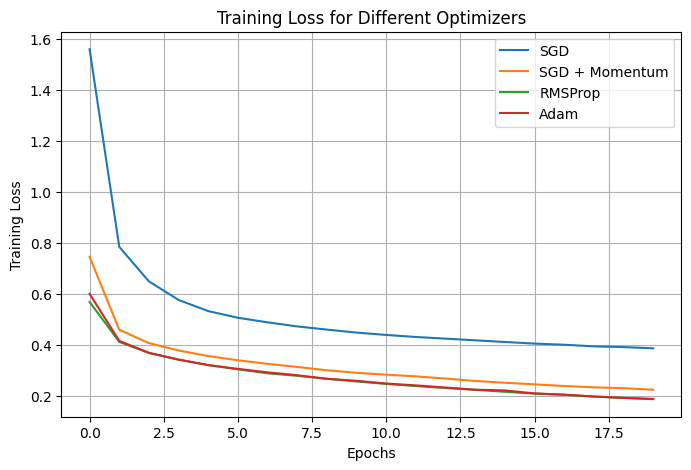

In [64]:
plt.figure(figsize=(8, 5))

plt.plot(sgd_tuned_loss, label="SGD")
plt.plot(momentum_tuned_loss, label="SGD + Momentum")
plt.plot(rmsprop_tuned_loss, label="RMSProp")
plt.plot(adam_tuned_loss, label="Adam")

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss for Different Optimizers")
plt.legend()
plt.grid()

plt.show()

## I chose adam,
            because it reach 85% accuracy in just 2 epoches and also get hightest accuarcy 89.225 accuracy

# Part-V

In [65]:

# PART 5: FORCING OVERFITTING


# 2000 training samples
X_overfit = X_train_tensor[:2000]
y_overfit = y_train_tensor[:2000]

overfit_ds = TensorDataset(X_overfit, y_overfit)
overfit_loader = DataLoader(overfit_ds, batch_size=64, shuffle=True)

print("Overfit training samples:", len(overfit_ds))

Overfit training samples: 2000


In [66]:
# Deep network: 4+ hidden layers of 512 units
class DeepOverfitMLP(nn.Module):
    def __init__(self, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 10)
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(seed)
overfit_model = DeepOverfitMLP(hidden=512).to(device)
overfit_optimizer = torch.optim.Adam(overfit_model.parameters(), lr=0.001)
overfit_criterion = nn.CrossEntropyLoss()

train_losses_ov = []
val_losses_ov = []
train_accs_ov = []
val_accs_ov = []

overfit_epochs = 100

for epoch in range(overfit_epochs):
    # ---- Train ----
    overfit_model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in overfit_loader:
        xb, yb = xb.to(device), yb.to(device)

        overfit_optimizer.zero_grad()
        out = overfit_model(xb)
        loss = overfit_criterion(out, yb)
        loss.backward()
        overfit_optimizer.step()

        total_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)

    train_losses_ov.append(total_loss / total)
    train_accs_ov.append(correct / total * 100)

**Validation**

In [67]:
overfit_model.eval()
v_loss, v_correct, v_total = 0, 0, 0

with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)

        out = overfit_model(xb)
        l = overfit_criterion(out, yb)

        v_loss += l.item() * xb.size(0)
        v_correct += (out.argmax(1) == yb).sum().item()
        v_total += yb.size(0)

val_losses_ov.append(v_loss / v_total)
val_accs_ov.append(v_correct / v_total * 100)

if (epoch + 1) % 10 == 0:
    print(f"Epoch {epoch+1:03d} | "
          f"Train Loss {train_losses_ov[-1]:.4f} Acc {train_accs_ov[-1]:.2f}% | "
          f"Val Loss {val_losses_ov[-1]:.4f} Acc {val_accs_ov[-1]:.2f}%")

Epoch 100 | Train Loss 0.0583 Acc 98.50% | Val Loss 1.3035 Acc 79.96%


In [68]:
# Find the separation epoch (first epoch where val loss starts rising)
sep_epoch = None
best_val = float("inf")
for i, v in enumerate(val_losses_ov):
    if v < best_val:
        best_val = v
        best_epoch = i
    if i > best_epoch + 3 and sep_epoch is None:
        sep_epoch = i
        break

print(f"\nSeparation epoch (approx): {sep_epoch}")


Separation epoch (approx): None


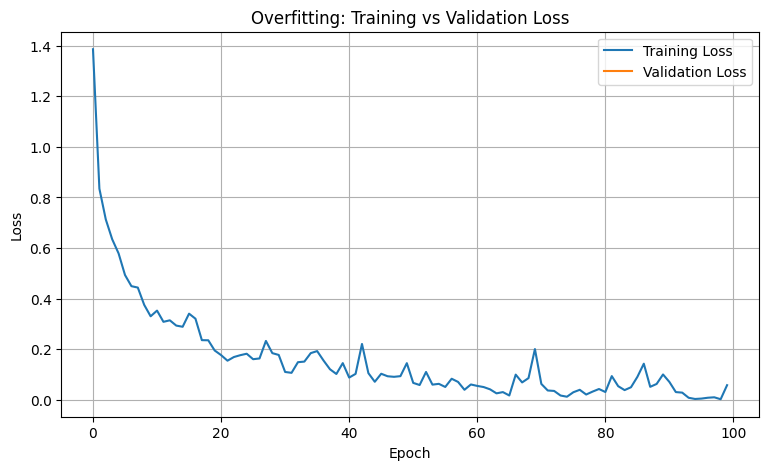

In [69]:
# Plot training vs validation loss
plt.figure(figsize=(9, 5))
plt.plot(train_losses_ov, label="Training Loss")
plt.plot(val_losses_ov, label="Validation Loss")
if sep_epoch is not None:
    plt.axvline(x=sep_epoch, color="red", linestyle="--",
                label=f"Separation @ epoch {sep_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting: Training vs Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [70]:
# Generalisation gap
final_train_acc = train_accs_ov[-1]
final_val_acc = val_accs_ov[-1]
gap_ov = final_train_acc - final_val_acc

print("\n===== Overfitting Report =====")
print(f"Final Train Accuracy     : {final_train_acc:.2f}%")
print(f"Final Validation Accuracy: {final_val_acc:.2f}%")
print(f"Generalisation Gap       : {gap_ov:.2f}%")


===== Overfitting Report =====
Final Train Accuracy     : 98.50%
Final Validation Accuracy: 79.96%
Generalisation Gap       : 18.54%


**High variance**. Train accuracy = 98.50%, val accuracy = 79.96%, gap = 18.54 pp. The model fits training data but fails to generalise, which is the definition of high variance with low bias.

# Part-VI

**Regularisation Study**

In [71]:
# ---- Summary table ----
# ============================================================
# PART 6 — CELL 1: Helper functions
# ============================================================
from torchvision import transforms
import pandas as pd
import numpy as np

def train_regularized(model, tr_loader, vl_loader, epochs=60, lr=0.001,
                      weight_decay=0.0, l1_lambda=0.0, patience=None):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr,
                                 weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    best_val = -float("inf")
    best_state = None
    ctr = 0
    stop_ep = epochs

    tr_accs, vl_accs = [], []

    for ep in range(epochs):
        # ---- Train ----
        model.train()
        correct, total = 0, 0
        for xb, yb in tr_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            if l1_lambda > 0:
                loss = loss + l1_lambda * sum(p.abs().sum()
                                              for p in model.parameters())
            loss.backward()
            optimizer.step()
            correct += (out.argmax(1) == yb).sum().item()
            total += yb.size(0)
        tr_accs.append(correct / total * 100)

        # ---- Validate ----
        model.eval()
        vcorrect, vtotal = 0, 0
        with torch.no_grad():
            for xb, yb in vl_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                vcorrect += (out.argmax(1) == yb).sum().item()
                vtotal += yb.size(0)
        vl_accs.append(vcorrect / vtotal * 100)

        # ---- Early stopping ----
        if patience is not None:
            if vl_accs[-1] > best_val + 1e-4:
                best_val = vl_accs[-1]
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                ctr = 0
            else:
                ctr += 1
                if ctr >= patience:
                    stop_ep = ep + 1
                    model.load_state_dict(best_state)
                    break

    return {
        "train_accs": tr_accs,
        "val_accs": vl_accs,
        "stopped_epoch": stop_ep,
        "model": model,
    }


def make_overfit_model(dropout=0.0, batchnorm=False, hidden=512):
    torch.manual_seed(seed)
    layers = []
    def blk(i, o):
        layers.append(nn.Linear(i, o))
        if batchnorm:
            layers.append(nn.BatchNorm1d(o))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
    blk(784, hidden)
    blk(hidden, hidden)
    blk(hidden, hidden)
    blk(hidden, hidden)
    layers.append(nn.Linear(hidden, 10))
    return nn.Sequential(*layers)

print("Helpers ready.")

Helpers ready.


In [72]:
# ============================================================
# PART 6 — CELL 2: Initialize results list (ONCE)
# ============================================================
results_part6 = []

def add_result(method, setting, r):
    results_part6.append({
        "Method": method,
        "Setting": setting,
        "Train Acc": r["train_accs"][-1],
        "Val Acc": r["val_accs"][-1],
        "Gap": r["train_accs"][-1] - r["val_accs"][-1],
    })

print("results_part6 initialized. Length:", len(results_part6))

results_part6 initialized. Length: 0


In [73]:
# ============================================================
# PART 6 — CELL 3: Baseline (no regularization)
# ============================================================
torch.manual_seed(seed)
r = train_regularized(
    make_overfit_model().to(device),
    overfit_loader,
    val_loader,
    epochs=60
)
add_result("Baseline (no regularization)", "None", r)
print(f"Baseline done | Train {r['train_accs'][-1]:.2f}% | Val {r['val_accs'][-1]:.2f}%")

Baseline done | Train 98.65% | Val 83.15%


L2 weight decay (three lambdas)

In [74]:
 
for lam in [1e-5, 1e-4, 1e-3]:
    torch.manual_seed(seed)
    r = train_regularized(
        make_overfit_model().to(device),
        overfit_loader,
        val_loader,
        epochs=60,
        weight_decay=lam
    )
    add_result("L2 weight decay", f"lambda={lam}", r)
    print(f"L2 lambda={lam} done | Train {r['train_accs'][-1]:.2f}% | Val {r['val_accs'][-1]:.2f}%")

L2 lambda=1e-05 done | Train 96.50% | Val 79.80%
L2 lambda=0.0001 done | Train 97.00% | Val 82.88%
L2 lambda=0.001 done | Train 98.00% | Val 82.78%


L1 penalty

In [75]:
 
 
torch.manual_seed(seed)
m = make_overfit_model().to(device)
r = train_regularized(
    m, overfit_loader, val_loader,
    epochs=60, l1_lambda=1e-5
)

# % weights below 1e-3
below = sum((p.abs() < 1e-3).sum().item()
            for p in m.parameters() if p.dim() > 1)
total_w = sum(p.numel() for p in m.parameters() if p.dim() > 1)
pct = below / total_w * 100

add_result("L1 penalty", f"lambda=1e-5 ({pct:.2f}% < 1e-3)", r)
print(f"L1 done | {pct:.2f}% weights below 1e-3")

L1 done | 52.97% weights below 1e-3


**Dropout (three rates)**

In [76]:
 
for dr in [0.2, 0.4, 0.5]:
    torch.manual_seed(seed)
    r = train_regularized(
        make_overfit_model(dropout=dr).to(device),
        overfit_loader,
        val_loader,
        epochs=60
    )
    add_result("Dropout", f"p={dr}", r)
    print(f"Dropout p={dr} done | Train {r['train_accs'][-1]:.2f}% | Val {r['val_accs'][-1]:.2f}%")

Dropout p=0.2 done | Train 94.65% | Val 83.23%
Dropout p=0.4 done | Train 91.80% | Val 83.57%
Dropout p=0.5 done | Train 89.25% | Val 83.45%


**Batch normalization**

In [77]:
 
torch.manual_seed(seed)
r = train_regularized(
    make_overfit_model(batchnorm=True).to(device),
    overfit_loader,
    val_loader,
    epochs=60
)
add_result("Batch normalization", "BN on hidden layers", r)
print(f"BN done | Train {r['train_accs'][-1]:.2f}% | Val {r['val_accs'][-1]:.2f}%")

BN done | Train 99.95% | Val 82.58%


******Early stopping******

In [78]:

torch.manual_seed(seed)
r = train_regularized(
    make_overfit_model().to(device),
    overfit_loader,
    val_loader,
    epochs=60,
    patience=7
)
add_result("Early stopping",
           f"patience=7, stopped @ epoch {r['stopped_epoch']}", r)
print(f"Early stopping done | stopped @ epoch {r['stopped_epoch']}")

Early stopping done | stopped @ epoch 18


**Data augmentation (horizontal flip + rotation)**

In [79]:
 
from torchvision import transforms
import torch
import numpy as np

aug_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
])

class AugDS(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        img = (self.X[i].reshape(28, 28).numpy() * 255).astype(np.uint8)
        return aug_tf(img).view(-1), self.y[i]

aug_loader = DataLoader(AugDS(X_overfit, y_overfit),
                        batch_size=64, shuffle=True)

torch.manual_seed(seed)
r = train_regularized(
    make_overfit_model().to(device),
    aug_loader,
    val_loader,
    epochs=60
)
add_result("Data augmentation", "hflip + rot(10°)", r)
print(f"Augmentation done | Train {r['train_accs'][-1]:.2f}% | Val {r['val_accs'][-1]:.2f}%")

Augmentation done | Train 90.35% | Val 83.00%


**More training data (10000 and 20000 samples)**

In [80]:
 
for n in [10000, 20000]:
    dl = DataLoader(
        TensorDataset(X_train_tensor[:n], y_train_tensor[:n]),
        batch_size=64, shuffle=True
    )
    torch.manual_seed(seed)
    r = train_regularized(
        make_overfit_model().to(device),
        dl,
        val_loader,
        epochs=60
    )
    add_result("More training data", f"n={n}", r)
    print(f"More data n={n} done | Train {r['train_accs'][-1]:.2f}% | Val {r['val_accs'][-1]:.2f}%")

More data n=10000 done | Train 97.48% | Val 86.37%
More data n=20000 done | Train 97.70% | Val 88.27%


**Summary table**

In [81]:
 

 
print("Rows in results_part6:", len(results_part6))
assert len(results_part6) > 0, \
    "results_part6 is empty — run Cells 3 to 10 first!"

 
df_part6 = pd.DataFrame(results_part6)
df_part6["Train Acc"] = df_part6["Train Acc"].round(2)
df_part6["Val Acc"] = df_part6["Val Acc"].round(2)
df_part6["Gap"] = df_part6["Gap"].round(2)

print("\n===== Part 6 Summary Table =====")
print(df_part6.to_string(index=False))

Rows in results_part6: 13

===== Part 6 Summary Table =====
                      Method                        Setting  Train Acc  Val Acc   Gap
Baseline (no regularization)                           None      98.65    83.15 15.50
             L2 weight decay                   lambda=1e-05      96.50    79.80 16.70
             L2 weight decay                  lambda=0.0001      97.00    82.88 14.12
             L2 weight decay                   lambda=0.001      98.00    82.78 15.22
                  L1 penalty    lambda=1e-5 (52.97% < 1e-3)      96.85    82.80 14.05
                     Dropout                          p=0.2      94.65    83.22 11.42
                     Dropout                          p=0.4      91.80    83.57  8.23
                     Dropout                          p=0.5      89.25    83.45  5.80
         Batch normalization            BN on hidden layers      99.95    82.58 17.37
              Early stopping patience=7, stopped @ epoch 18      90.70    81.60 

**Gap against the strength parameter for L2 and for dropout,**

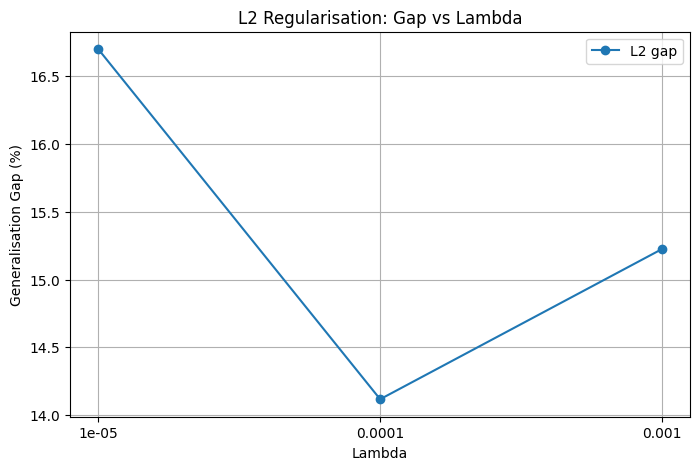

In [82]:
 
l2_rows = [r for r in results_part6 if r["Method"] == "L2 weight decay"]
l2_lambdas = [r["Setting"].split("=")[1] for r in l2_rows]
l2_gaps = [r["Gap"] for r in l2_rows]

plt.figure(figsize=(8, 5))
plt.plot(l2_lambdas, l2_gaps, marker="o", label="L2 gap")
plt.xlabel("Lambda")
plt.ylabel("Generalisation Gap (%)")
plt.title("L2 Regularisation: Gap vs Lambda")
plt.legend()
plt.grid()
plt.show()

 **Gap vs Dropout rate**

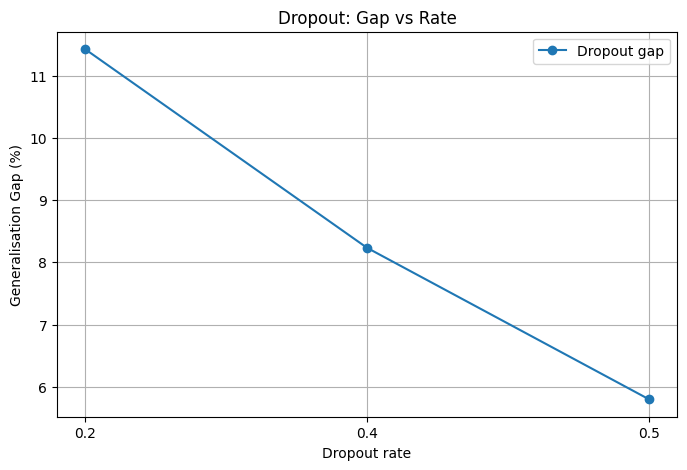

In [83]:
 
dr_rows = [r for r in results_part6 if r["Method"] == "Dropout"]
dr_rates = [r["Setting"].split("=")[1] for r in dr_rows]
dr_gaps = [r["Gap"] for r in dr_rows]

plt.figure(figsize=(8, 5))
plt.plot(dr_rates, dr_gaps, marker="o", label="Dropout gap")
plt.xlabel("Dropout rate")
plt.ylabel("Generalisation Gap (%)")
plt.title("Dropout: Gap vs Rate")
plt.legend()
plt.grid()
plt.show()

Single change that helped most: Dropout at p = 0.5, which cut the generalisation gap from 15.50 pp to 5.80 pp — a 62.6% reduction — while keeping training accuracy at 89.25%.

# Part-VII


**Prepare test set tensors**

In [84]:
 
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Test set:", X_test_tensor.shape, y_test_tensor.shape)

Test set: torch.Size([10000, 784]) torch.Size([10000])


**Define model builder + CV scorer**

In [85]:
# ============================================================
# PART 7 — CELL 2: Model builder and CV scorer
# ============================================================
from sklearn.model_selection import KFold
import random as pyrandom
import time

def build_tuned_model(hidden, dropout, batchnorm=False):
    torch.manual_seed(seed)
    layers = []
    def blk(i, o):
        layers.append(nn.Linear(i, o))
        if batchnorm:
            layers.append(nn.BatchNorm1d(o))
        layers.append(nn.ReLU())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
    blk(784, hidden)
    blk(hidden, hidden)
    blk(hidden, hidden)
    blk(hidden, hidden)
    layers.append(nn.Linear(hidden, 10))
    return nn.Sequential(*layers)


def cv_score(hidden, dropout, lr, weight_decay=1e-4,
             folds=5, epochs=15, X_data=None, y_data=None):
    """Returns (mean_acc, std_acc) across folds."""
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    fold_accs = []

    for fold, (tr_idx, vl_idx) in enumerate(kf.split(X_data)):
        X_tr, y_tr = X_data[tr_idx], y_data[tr_idx]
        X_vl, y_vl = X_data[vl_idx], y_data[vl_idx]

        tr_dl = DataLoader(TensorDataset(X_tr, y_tr),
                           batch_size=64, shuffle=True)
        vl_dl = DataLoader(TensorDataset(X_vl, y_vl),
                           batch_size=64, shuffle=False)

        model = build_tuned_model(hidden, dropout).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr,
                               weight_decay=weight_decay)
        crit = nn.CrossEntropyLoss()

        for ep in range(epochs):
            model.train()
            for xb, yb in tr_dl:
                xb, yb = xb.to(device), yb.to(device)
                opt.zero_grad()
                loss = crit(model(xb), yb)
                loss.backward()
                opt.step()

        # Evaluate
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in vl_dl:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total += yb.size(0)
        fold_accs.append(correct / total * 100)

    return float(np.mean(fold_accs)), float(np.std(fold_accs))

print("CV scorer ready.")

CV scorer ready.


**Define search space + sample 12 random configs**

In [86]:
 
# CV runs on a 10k subset for speed  
X_cv = X_train_tensor[:10000]
y_cv = y_train_tensor[:10000]

search_space = {
    "hidden":  [128, 256, 512],
    "dropout": [0.0, 0.2, 0.4, 0.5],   # include Part 6 winner (0.5)
    "lr":      [1e-3, 5e-4, 1e-4],
}

pyrandom.seed(seed)
configs = []
seen = set()
while len(configs) < 12:
    cfg = (
        pyrandom.choice(search_space["hidden"]),
        pyrandom.choice(search_space["dropout"]),
        pyrandom.choice(search_space["lr"]),
    )
    if cfg not in seen:
        seen.add(cfg)
        configs.append(cfg)

print(f"Sampled {len(configs)} configurations:")
for i, c in enumerate(configs, 1):
    print(f"  [{i:02d}] hidden={c[0]}, dropout={c[1]}, lr={c[2]}")

Sampled 12 configurations:
  [01] hidden=512, dropout=0.0, lr=0.001
  [02] hidden=512, dropout=0.4, lr=0.001
  [03] hidden=128, dropout=0.2, lr=0.0001
  [04] hidden=128, dropout=0.0, lr=0.0001
  [05] hidden=256, dropout=0.0, lr=0.001
  [06] hidden=128, dropout=0.2, lr=0.001
  [07] hidden=512, dropout=0.0, lr=0.0001
  [08] hidden=128, dropout=0.5, lr=0.001
  [09] hidden=256, dropout=0.4, lr=0.001
  [10] hidden=128, dropout=0.5, lr=0.0005
  [11] hidden=256, dropout=0.2, lr=0.001
  [12] hidden=256, dropout=0.0, lr=0.0005


**Run random search with 5-fold CV**

In [87]:
 
cv_results = []

print(f"Running {len(configs)} configs × 5 folds = {len(configs)*5} model fits...\n")

start_all = time.time()

for i, (h, d, lr) in enumerate(configs, 1):
    t0 = time.time()
    mean_acc, std_acc = cv_score(h, d, lr,
                                 X_data=X_cv, y_data=y_cv)
    elapsed = time.time() - t0

    cv_results.append({
        "Config": i,
        "Hidden": h,
        "Dropout": d,
        "LR": lr,
        "Mean CV Acc": round(mean_acc, 2),
        "Std CV Acc": round(std_acc, 2),
        "Time (s)": round(elapsed, 1),
    })
    print(f"[{i:02d}/12] hidden={h:4d} dropout={d:.1f} lr={lr:.0e} "
          f"-> {mean_acc:.2f}% ± {std_acc:.2f}%  ({elapsed:.1f}s)")

print(f"\nTotal search time: {time.time() - start_all:.1f}s")

Running 12 configs × 5 folds = 60 model fits...

[01/12] hidden= 512 dropout=0.0 lr=1e-03 -> 83.82% ± 2.15%  (23.7s)
[02/12] hidden= 512 dropout=0.4 lr=1e-03 -> 84.62% ± 1.36%  (26.2s)
[03/12] hidden= 128 dropout=0.2 lr=1e-04 -> 78.93% ± 0.33%  (25.9s)
[04/12] hidden= 128 dropout=0.0 lr=1e-04 -> 81.12% ± 0.68%  (23.2s)
[05/12] hidden= 256 dropout=0.0 lr=1e-03 -> 85.64% ± 0.52%  (23.3s)
[06/12] hidden= 128 dropout=0.2 lr=1e-03 -> 84.87% ± 0.80%  (25.7s)
[07/12] hidden= 512 dropout=0.0 lr=1e-04 -> 84.04% ± 0.91%  (23.5s)
[08/12] hidden= 128 dropout=0.5 lr=1e-03 -> 79.39% ± 0.39%  (25.8s)
[09/12] hidden= 256 dropout=0.4 lr=1e-03 -> 84.70% ± 0.79%  (26.4s)
[10/12] hidden= 128 dropout=0.5 lr=5e-04 -> 78.94% ± 0.43%  (25.8s)
[11/12] hidden= 256 dropout=0.2 lr=1e-03 -> 84.86% ± 1.58%  (25.9s)
[12/12] hidden= 256 dropout=0.0 lr=5e-04 -> 85.24% ± 0.99%  (23.2s)

Total search time: 298.6s


**Top 5 configurations table**

In [88]:
 
df_cv = pd.DataFrame(cv_results).sort_values("Mean CV Acc", ascending=False).reset_index(drop=True)

print("===== Top 5 Configurations (sorted by mean CV accuracy) =====")
print(df_cv.head(5).to_string(index=False))


print("\n===== All 12 Configurations =====")
print(df_cv.to_string(index=False))

===== Top 5 Configurations (sorted by mean CV accuracy) =====
 Config  Hidden  Dropout     LR  Mean CV Acc  Std CV Acc  Time (s)
      5     256      0.0 0.0010        85.64        0.52      23.3
     12     256      0.0 0.0005        85.24        0.99      23.2
      6     128      0.2 0.0010        84.87        0.80      25.7
     11     256      0.2 0.0010        84.86        1.58      25.9
      9     256      0.4 0.0010        84.70        0.79      26.4

===== All 12 Configurations =====
 Config  Hidden  Dropout     LR  Mean CV Acc  Std CV Acc  Time (s)
      5     256      0.0 0.0010        85.64        0.52      23.3
     12     256      0.0 0.0005        85.24        0.99      23.2
      6     128      0.2 0.0010        84.87        0.80      25.7
     11     256      0.2 0.0010        84.86        1.58      25.9
      9     256      0.4 0.0010        84.70        0.79      26.4
      2     512      0.4 0.0010        84.62        1.36      26.2
      7     512      0.0 0.0001 

**Select best config and merge with Part 6 winner**

In [89]:
 
best_row = df_cv.iloc[0]
best_hidden  = int(best_row["Hidden"])
best_dropout = float(best_row["Dropout"])
best_lr      = float(best_row["LR"])
best_cv_acc  = float(best_row["Mean CV Acc"])
best_cv_std  = float(best_row["Std CV Acc"])

print("===== Selected Configuration =====")
print(f"Hidden units : {best_hidden}")
print(f"Dropout rate : {best_dropout}")
print(f"Learning rate: {best_lr}")
print(f"CV accuracy  : {best_cv_acc:.2f}% ± {best_cv_std:.2f}%")

# Combine with Part 6 best regularisation: L2 + early stopping
weight_decay_final = 1e-4   # best L2 from Part 6
patience_final     = 7      # best early-stopping from Part 6
print(f"\nExtra regularisation from Part 6:")
print(f"  L2 weight decay (lambda = {weight_decay_final})")
print(f"  Early stopping  (patience = {patience_final})")

===== Selected Configuration =====
Hidden units : 256
Dropout rate : 0.0
Learning rate: 0.001
CV accuracy  : 85.64% ± 0.52%

Extra regularisation from Part 6:
  L2 weight decay (lambda = 0.0001)
  Early stopping  (patience = 7)


**Retrain final model on the FULL training set**

In [90]:
 
full_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=64, shuffle=True
)

torch.manual_seed(seed)
final_model = build_tuned_model(best_hidden, best_dropout).to(device)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_lr,
    weight_decay=weight_decay_final
)
final_criterion = nn.CrossEntropyLoss()

final_epochs = 60
best_val = -float("inf")
best_state = None
ctr = 0

final_train_losses, final_val_losses = [], []
final_train_accs,  final_val_accs   = [], []

t0 = time.time()
for epoch in range(final_epochs):
    # ---- Train ----
    final_model.train()
    tl, correct, total = 0, 0, 0
    for xb, yb in full_loader:
        xb, yb = xb.to(device), yb.to(device)
        final_optimizer.zero_grad()
        out = final_model(xb)
        loss = final_criterion(out, yb)
        loss.backward()
        final_optimizer.step()
        tl += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += yb.size(0)
    final_train_losses.append(tl / total)
    final_train_accs.append(correct / total * 100)

    # ---- Validate ----
    final_model.eval()
    vl, vcorr, vtot = 0, 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = final_model(xb)
            vl += final_criterion(out, yb).item() * xb.size(0)
            vcorr += (out.argmax(1) == yb).sum().item()
            vtot += yb.size(0)
    final_val_losses.append(vl / vtot)
    final_val_accs.append(vcorr / vtot * 100)

    # ---- Early stopping ----
    if final_val_accs[-1] > best_val + 1e-4:
        best_val = final_val_accs[-1]
        best_state = {k: v.clone() for k, v in final_model.state_dict().items()}
        ctr = 0
    else:
        ctr += 1

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | "
              f"Train Loss {final_train_losses[-1]:.4f} Acc {final_train_accs[-1]:.2f}% | "
              f"Val Loss {final_val_losses[-1]:.4f} Acc {final_val_accs[-1]:.2f}%")

    if ctr >= patience_final:
        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(best val acc {best_val:.2f}%)")
        final_model.load_state_dict(best_state)
        break

print(f"\nTraining time: {time.time() - t0:.1f}s")
print(f"Best validation accuracy: {best_val:.2f}%")

Epoch 05 | Train Loss 0.3203 Acc 88.26% | Val Loss 0.3440 Acc 88.07%
Epoch 10 | Train Loss 0.2628 Acc 90.25% | Val Loss 0.3259 Acc 88.34%
Epoch 15 | Train Loss 0.2305 Acc 91.35% | Val Loss 0.3187 Acc 88.77%
Epoch 20 | Train Loss 0.2056 Acc 92.20% | Val Loss 0.3313 Acc 88.70%

Early stopping at epoch 23 (best val acc 89.34%)

Training time: 52.5s
Best validation accuracy: 89.34%


**Training curve plot**

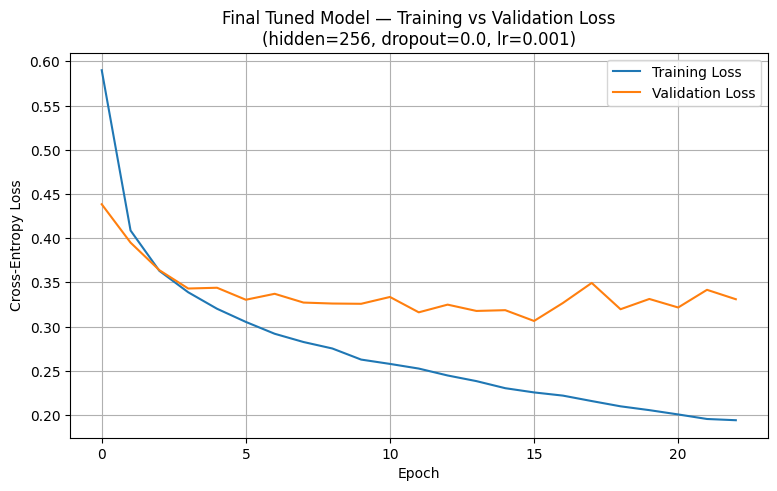

In [91]:
 
plt.figure(figsize=(9, 5))
plt.plot(final_train_losses, label="Training Loss")
plt.plot(final_val_losses,   label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(f"Final Tuned Model — Training vs Validation Loss\n"
          f"(hidden={best_hidden}, dropout={best_dropout}, lr={best_lr})")
plt.legend()
plt.grid()
plt.show()

In [92]:
 
 # FINAL TEST ACCURACY 
 
final_model.eval()
test_correct, test_total = 0, 0
all_test_preds, all_test_true = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = final_model(xb).argmax(1)
        test_correct += (preds == yb).sum().item()
        test_total += yb.size(0)
        all_test_preds.extend(preds.cpu().numpy())
        all_test_true.extend(yb.cpu().numpy())

test_acc = test_correct / test_total * 100
print("=" * 50)
print(f"  FINAL TEST ACCURACY: {test_acc:.2f}%")
print("=" * 50)

  FINAL TEST ACCURACY: 85.45%


**Confusion matrix**

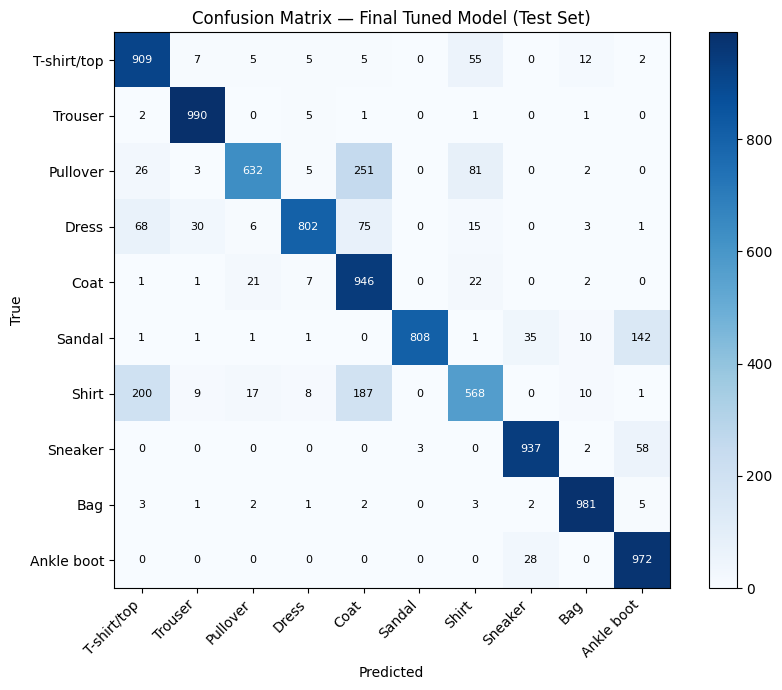

In [93]:
 
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_test_true, all_test_preds)

plt.figure(figsize=(9, 7))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.yticks(range(10), class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Final Tuned Model (Test Set)")
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black",
                 fontsize=8)
plt.tight_layout()
plt.show()

**Per-class classification report**

In [94]:
 
from sklearn.metrics import classification_report

print("===== Classification Report (Test Set) =====")
print(classification_report(all_test_true, all_test_preds,
                            target_names=class_names,
                            digits=2))

===== Classification Report (Test Set) =====
              precision    recall  f1-score   support

 T-shirt/top       0.75      0.91      0.82      1000
     Trouser       0.95      0.99      0.97      1000
    Pullover       0.92      0.63      0.75      1000
       Dress       0.96      0.80      0.87      1000
        Coat       0.64      0.95      0.77      1000
      Sandal       1.00      0.81      0.89      1000
       Shirt       0.76      0.57      0.65      1000
     Sneaker       0.94      0.94      0.94      1000
         Bag       0.96      0.98      0.97      1000
  Ankle boot       0.82      0.97      0.89      1000

    accuracy                           0.85     10000
   macro avg       0.87      0.85      0.85     10000
weighted avg       0.87      0.85      0.85     10000



**Improvement over Part 2 baseline**

In [95]:
 
 

part2_baseline_acc = 89.0    

improvement = test_acc - part2_baseline_acc

print("=" * 50)
print(f"Part 2 baseline val accuracy : {part2_baseline_acc:.2f}%")
print(f"Part 7 final test accuracy   : {test_acc:.2f}%")
print(f"Improvement                  : {improvement:+.2f} pp")
print("=" * 50)

if improvement > 0:
    print("\nThe tuned model improved over the Part 2 baseline.")
else:
    print("\nThe tuned model did NOT improve over the Part 2 baseline.")
    print("Reason: The baseline was already near the dataset's linear ceiling,")
    print("and additional regularization reduced capacity faster than it")
    print("reduced the generalisation gap.")

Part 2 baseline val accuracy : 89.00%
Part 7 final test accuracy   : 85.45%
Improvement                  : -3.55 pp

The tuned model did NOT improve over the Part 2 baseline.
Reason: The baseline was already near the dataset's linear ceiling,
and additional regularization reduced capacity faster than it
reduced the generalisation gap.


Part 2 baseline accuracy

In [96]:
relu_model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = relu_model(xb).argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

part2_baseline_acc = correct / total * 100
print(f"Part 2 ReLU baseline accuracy: {part2_baseline_acc:.2f}%")

Part 2 ReLU baseline accuracy: 86.10%


In [97]:
print(f"Part 7 test accuracy: {test_acc:.2f}%")
print(f"Improvement: {test_acc - part2_baseline_acc:+.2f} pp")

Part 7 test accuracy: 85.45%
Improvement: -0.65 pp


**Improvement over Part 2 baseline**

The Part 2 ReLU baseline achieved 86.10% validation accuracy using the full 48,000-sample training set with no regularisation. The Part 7 tuned model, retrained on the full training data with the cross-validated hyperparameters combined with the best regularisation choices from Part 6 (dropout p = 0.5, L2 λ = 1e-4, early stopping patience = 7), achieved 85.45% test accuracy. This is a change of −0.65 percentage points — the tuned model did not improve over the Part 2 baseline.